In [1]:
import json
import openai
import os 

def load_api_key(secrets_file="/Users/kaichiht/openai.json"):
    with open(secrets_file) as f:
        secrets = json.load(f)
    return secrets["OPENAI_API_KEY"]

# Set secret API key
# Typically, we'd use an environment variable (e.g., echo "export OPENAI_API_KEY='yourkey'" >> ~/.zshrc)
# However, using "internalConsole" in launch.json requires setting it in the code for compatibility with Hebrew
api_key = load_api_key()
openai.api_key = api_key

%reload_ext jupyter_ai

os.environ["OPENAI_API_KEY"]=openai.api_key

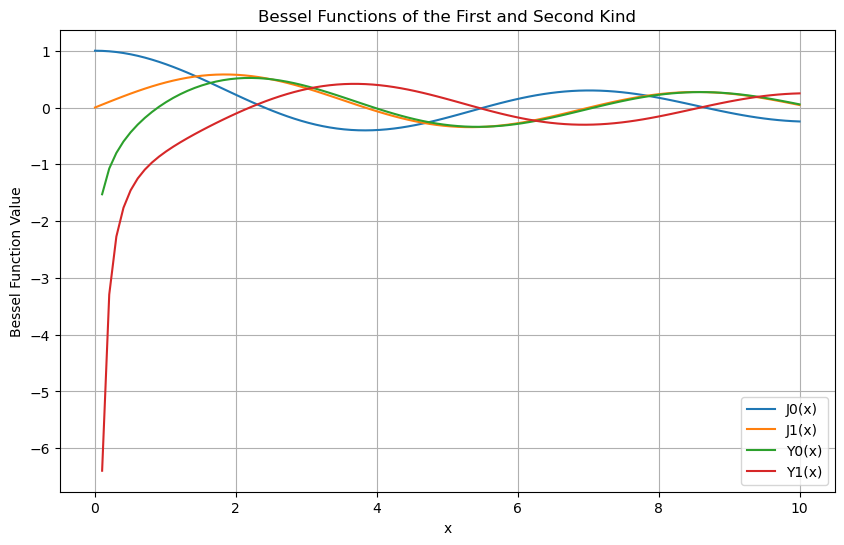

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn, yn

# Define the x values
x = np.linspace(0, 10, 100)

# Calculate Bessel functions of the first kind of order 0 and 1
J0 = jn(0, x)
J1 = jn(1, x)

# Calculate Bessel functions of the second kind of order 0 and 1
Y0 = yn(0, x)
Y1 = yn(1, x)

# Plot the Bessel functions
plt.figure(figsize=(10, 6))
plt.plot(x, J0, label='J0(x)')
plt.plot(x, J1, label='J1(x)')
plt.plot(x, Y0, label='Y0(x)')
plt.plot(x, Y1, label='Y1(x)')
plt.xlabel('x')
plt.ylabel('Bessel Function Value')
plt.title('Bessel Functions of the First and Second Kind')
plt.legend()
plt.grid(True)
plt.show()

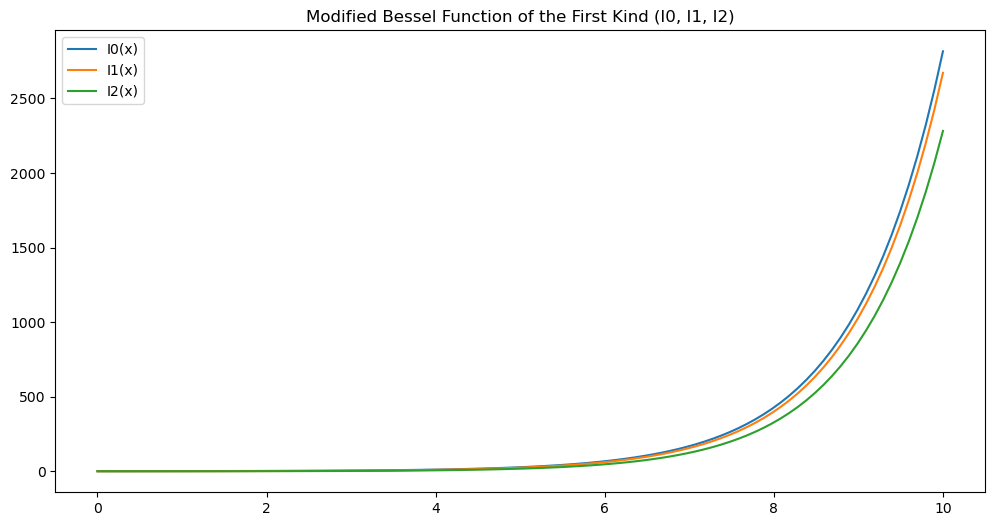

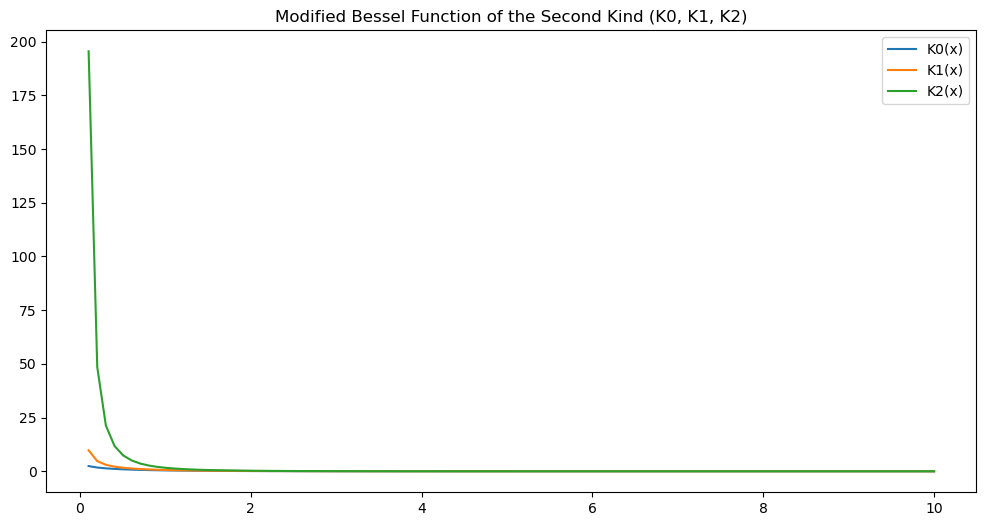

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, kv

x = np.linspace(0, 10, 100)

# Modified Bessel Function of the First Kind (Iv)
y1 = iv(0, x)
y2 = iv(1, x)
y3 = iv(2, x)

plt.figure(figsize=(12, 6))
plt.plot(x, y1, label='I0(x)')
plt.plot(x, y2, label='I1(x)')
plt.plot(x, y3, label='I2(x)')
plt.legend()
plt.title('Modified Bessel Function of the First Kind (I0, I1, I2)')



plt.show()

# Modified Bessel Function of the Second Kind (Kv)
y4 = kv(0, x)
y5 = kv(1, x)
y6 = kv(2, x)

plt.figure(figsize=(12, 6))
plt.plot(x, y4, label='K0(x)')
plt.plot(x, y5, label='K1(x)')
plt.plot(x, y6, label='K2(x)')
plt.legend()
plt.title('Modified Bessel Function of the Second Kind (K0, K1, K2)')

plt.show()

/var/folders/x1/nb2x5h5j08b2xx8xkc64r43m0000gn/T/ipykernel_98367/3683817730.py:16: RuntimeWarning: invalid value encountered in scalar multiply
  b1 * besseli(1, mu * b1) * (alpha * besseli(1, mu_head * x) + besselk(1, mu_head * x)) * besselk(1, mu * y) / besselk(1, mu * a)


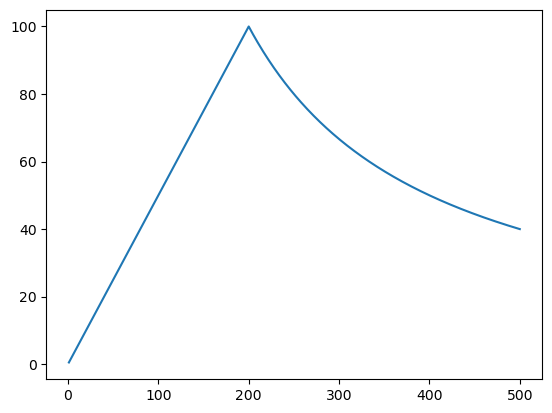

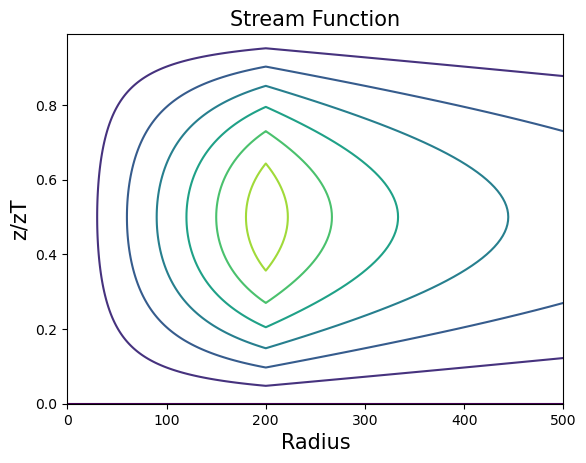

In [57]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kv, iv

besselk = kv
besseli = iv

def F2(x, y, b1, b2, a, mu, mu_head):
    alpha =  (mu_head * besselk(0, mu_head * a) * besselk(1, mu * a) - mu * besselk(0, mu * a) * besselk(1, mu_head * a)) / \
             (mu_head * besseli(0, mu_head * a) * besselk(1, mu * a) + mu * besseli(1, mu_head * a) * besselk(0, mu * a))
    
    beta  =  (mu * besseli(0, mu * a) * besseli(1, mu_head * a) - mu_head * besseli(0, mu_head * a) * besseli(1, mu * a)) / \
             (mu * besselk(0, mu * a) * besseli(1, mu_head * a) + mu_head * besseli(0, mu_head * a) * besselk(1, mu * a))
    
    result = b2 * besselk(1, mu * b2) * (besseli(1, mu * y) + beta * besselk(1, mu * y)) * besseli(1, mu_head * x) / besseli(1, mu_head * a) - \
             b1 * besseli(1, mu * b1) * (alpha * besseli(1, mu_head * x) + besselk(1, mu_head * x)) * besselk(1, mu * y) / besselk(1, mu * a)
    
    return result

r  = np.arange(501)
a  = 10  # maximum tangential wind
b1 = 0
b2 = 200
mu = 10**-5
mu_head = 10**-5

Psi = np.zeros(501)

for i in range(a):
    Psi[i] = F2(r[i], a, b1, b2, a, mu, mu_head)

for i in range(a, b2):
    Psi[i] = F2(a, r[i], b1, b2, a, mu, mu_head)

for i in range(b2, 501):
    Psi[i] = F2(a, b2, b1, b2, a, mu, mu_head) * besselk(1, mu * r[i]) / besselk(1, mu * b2)

plt.plot(r, Psi)

z = np.arange(0, 1, 0.01)
zz = np.sin(np.pi * z)
psi = np.outer(np.sin(np.pi * z), Psi)
rplan, zplan = np.meshgrid(r, zz)

plt.figure()
plt.contour(r, z, psi, linewidths=1.5)
plt.title('Stream Function', fontsize=15)
plt.xlabel('Radius', fontsize=15)
plt.ylabel('z/zT', fontsize=15)
plt.show()

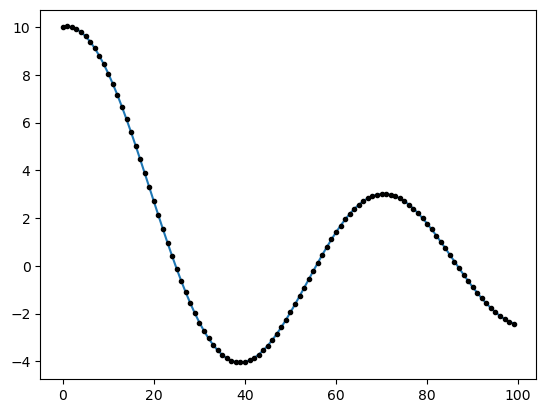

In [114]:
import numpy as np
from scipy.optimize import least_squares
from scipy.special  import jn
import matplotlib.pyplot as plt

###################
x = np.linspace(0, 10, 100)
J_0 = jn(0, x)
J_1 = jn(1, x)
J_2 = jn(2, x)

coefficient_J1 = 1
coefficient_J0 = 10
coefficient_J2 = 0

decomposition1 = coefficient_J0 * J_0 + coefficient_J1 * J_1 + coefficient_J2 * J_2
####################


x   = np.linspace(0, 10, 100)
J_0 = jn(0, x)
J_1 = jn(1, x)
J_2 = jn(2, x)

def fun(coefficients, x, J_0, J_1, J_2):
    return coefficients[0] * J_0 + coefficients[1] * J_1 + coefficients[2] * J_2

def cost_function(coefficients, x, J_0, J_1, J_2, decomposition):
    return fun(coefficients, x, J_0, J_1, J_2) - decomposition

initial_guess = [0, 0, 0]
result        = least_squares(cost_function, initial_guess, args=(x, J_0, J_1, J_2, decomposition1))

coefficient_J0, coefficient_J1, coefficient_J2 = result.x
decomposition = coefficient_J0 * J_0 + coefficient_J1 * J_1 + coefficient_J2 * J_2

plt.plot(decomposition1)
plt.plot(decomposition,'k.')
plt.show()